In [156]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = None

for path in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier src depuis {CURRENT_DIR}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new


In [157]:
from src.modeling.evaluation import (
    find_best_f1_threshold,
    find_ks_threshold,
    plot_ks_curve,
    classification_metrics,
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
)
from src.features.feature_selection import (
    remove_correlated_features,
)

## 1. Import Train and Test Data

In [158]:
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SPLIT_DIR = PROJECT_ROOT / "data" / "processed" / "pd_split"
REPORT_DIR = PROJECT_ROOT / "reports" / "pd_binning"

X_train_woe = pd.read_parquet(
    REPORT_DIR / "X_train_woe.parquet"
)

X_test_woe = pd.read_parquet(
    REPORT_DIR / "X_test_woe.parquet"
)

y_train = pd.read_parquet(
    SPLIT_DIR / "y_train.parquet"
).squeeze()

y_test = pd.read_parquet(
    SPLIT_DIR / "y_test.parquet"
).squeeze()

iv_report = pd.read_csv(
    REPORT_DIR / "iv_report.csv"
)

print("X_train:", X_train_woe.shape)
print("X_test :", X_test_woe.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (373028, 49)
X_test : (93257, 49)
y_train: (373028, 2)
y_test : (93257, 2)


In [159]:
print(y_train.columns)

Index(['source_row_index', 'good_bad'], dtype='object')


## 2. Features selection base on Information Value(IV)

In [160]:
IV_THRESHOLD = 0.005

selected_variables = (
    iv_report.loc[
        iv_report["information_value"] >= IV_THRESHOLD,
        "variable",
    ]
    .tolist()
)

selected_features = [
    f"{variable}_woe"
    for variable in selected_variables
    if f"{variable}_woe" in X_train_woe.columns
]

print(f"Variables selected with IV >= {IV_THRESHOLD}: {len(selected_features)}")
print(selected_features)

Variables selected with IV >= 0.005: 27
['int_rate_woe', 'grade_woe', 'loan_burden_interest_woe', 'installment_to_income_ratio_woe', 'tot_cur_bal_woe', 'total_rev_hi_lim_woe', 'loan_to_income_ratio_woe', 'credit_inquiry_rate_woe', 'annual_inc_woe', 'inq_last_6mths_woe', 'term_woe', 'purpose_woe', 'tot_coll_amt_woe', 'credit_history_months_woe', 'revol_util_woe', 'initial_list_status_woe', 'dti_woe', 'verification_status_woe', 'home_ownership_woe', 'addr_state_woe', 'open_account_ratio_woe', 'investor_funding_ratio_woe', 'total_acc_woe', 'emp_length_years_woe', 'revol_bal_woe', 'installment_woe', 'mths_since_last_record_woe']


In [161]:
X_train_model = X_train_woe[selected_features].copy()
X_test_model = X_test_woe[selected_features].copy()
y_train_model = y_train["good_bad"].copy()
y_test_model = y_test["good_bad"].copy()

#conversion of good_bad to 0/1 for modeling: 0 = good, 1 = Bad / Default
y_train_model = 1 - y_train["good_bad"]
y_test_model = 1 - y_test["good_bad"]

print("Train model shape:", X_train_model.shape)
print("Test model shape :", X_test_model.shape)
print("Train target shape:", y_train_model.shape)
print("Test target shape :", y_test_model.shape)

Train model shape: (373028, 27)
Test model shape : (93257, 27)
Train target shape: (373028,)
Test target shape : (93257,)


Correlation analysis was performed on the WoE-transformed variables rather than the raw variables. After the Weight of Evidence (WoE) transformation, both numerical and categorical variables are represented on a common numerical risk scale, making Pearson correlation analysis meaningful. This approach identifies variables carrying redundant predictive information, allowing the model to retain only the most informative feature among highly correlated variables based on their Information Value (IV).

In [162]:
selected_features, removed_features, correlation_report = (
    remove_correlated_features(
        X_train_model,
        iv_report,
        threshold=0.9,
    )
)

display(correlation_report)

,removed_feature,kept_feature,correlation,removed_iv,kept_iv,reason
0,grade_woe,int_rate_woe,0.918,0.2921,0.3194,Lower IV among correlated features


In [163]:
corr_matrix = X_train_model.corr()

#corr_matrix.round(2)

In [164]:
X_train_model = X_train_model[selected_features]

X_test_model = X_test_model[selected_features]

print("Train model shape after removing correlated features:", X_train_model.shape)
print("Test model shape after removing correlated features :", X_test_model.shape)

Train model shape after removing correlated features: (373028, 26)
Test model shape after removing correlated features : (93257, 26)


In [165]:
X_train_model.isnull().sum()

int_rate_woe                       0
loan_burden_interest_woe           0
installment_to_income_ratio_woe    0
tot_cur_bal_woe                    0
total_rev_hi_lim_woe               0
loan_to_income_ratio_woe           0
credit_inquiry_rate_woe            0
annual_inc_woe                     0
inq_last_6mths_woe                 0
term_woe                           0
purpose_woe                        0
tot_coll_amt_woe                   0
credit_history_months_woe          0
revol_util_woe                     0
initial_list_status_woe            0
dti_woe                            0
verification_status_woe            0
home_ownership_woe                 0
addr_state_woe                     0
open_account_ratio_woe             0
investor_funding_ratio_woe         0
total_acc_woe                      0
emp_length_years_woe               0
revol_bal_woe                      0
installment_woe                    0
mths_since_last_record_woe         0
dtype: int64

## 3. Train logistic regression

In [166]:
from sklearn.linear_model import LogisticRegression

pd_model = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42,
)

pd_model.fit(
    X_train_model,
    y_train_model,
)

print("Model trained successfully.")
print("Number of features:", X_train_model.shape[1])

Model trained successfully.
Number of features: 26


In [167]:
train_pd = pd_model.predict_proba(
    X_train_model
)[:, 1]

test_pd = pd_model.predict_proba(
    X_test_model
)[:, 1]

In [168]:
test_prob = pd_model.predict_proba(X_test_model)[:,1]

pd.Series(test_prob).describe()

count    93257.000000
mean         0.109412
std          0.069348
min          0.007768
25%          0.056796
50%          0.093807
75%          0.148013
max          0.519186
dtype: float64

In [169]:
#best treshold according to f1 score
'''best_f1_threshold, threshold_report = (
    find_best_f1_threshold(
        y_true=y_test_model,
        probabilities=test_prob,
    )
)

print(
    f"Best threshold: {best_f1_threshold:.2f}"
)

display(
    threshold_report.sort_values(
        "f1_score",
        ascending=False,
    ).head(10)
)'''

'best_f1_threshold, threshold_report = (\n    find_best_f1_threshold(\n        y_true=y_test_model,\n        probabilities=test_prob,\n    )\n)\n\nprint(\n    f"Best threshold: {best_f1_threshold:.2f}"\n)\n\ndisplay(\n    threshold_report.sort_values(\n        "f1_score",\n        ascending=False,\n    ).head(10)\n)'

Kolmogorov-Smirnov (KS) statistic is a measure of the maximum difference between the cumulative distribution functions (CDFs) of two samples. In credit scoring, it is often used to evaluate the discriminatory power of a model by comparing the distributions of predicted probabilities for good and bad borrowers.


In [170]:
ks_threshold, ks_value, ks_report = find_ks_threshold(
    y_true=y_test_model,
    probabilities=test_prob,
)

print(f"KS threshold : {ks_threshold:.4f}")
print(f"KS statistic : {ks_value:.4f}")
print(f"KS percentage: {ks_value * 100:.2f}%")

KS threshold : 0.1101
KS statistic : 0.2789
KS percentage: 27.89%


In [171]:
metrics = classification_metrics(
    y_true=y_test_model,
    probabilities=test_prob,
    threshold=ks_threshold
)
print(metrics)

      metric     value
0   accuracy  0.625025
1  precision  0.175626
2     recall  0.657936
3   f1_score  0.277246
4    roc_auc  0.691002
5       gini  0.382005


In [172]:
print_classification_report(
    y_true=y_test_model,
    probabilities=test_prob,
    threshold=ks_threshold,
)

              precision    recall  f1-score   support

        Good       0.94      0.62      0.75     83063
         Bad       0.18      0.66      0.28     10194

    accuracy                           0.63     93257
   macro avg       0.56      0.64      0.51     93257
weighted avg       0.85      0.63      0.70     93257



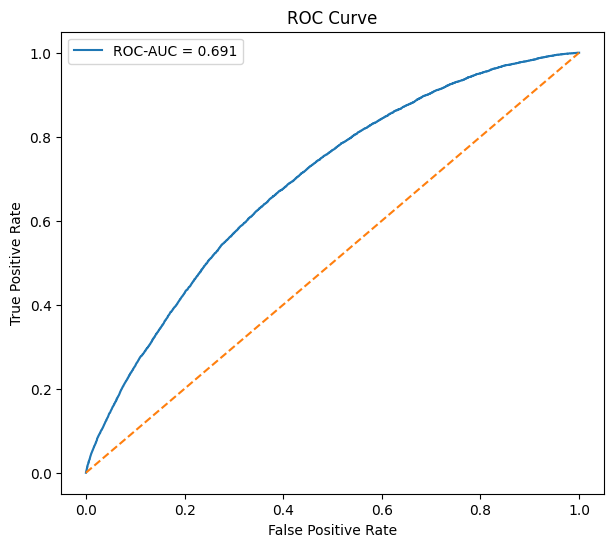

0.6910024855179939

In [173]:
plot_roc_curve(
    y_true=y_test_model,
    probabilities=test_prob,
)

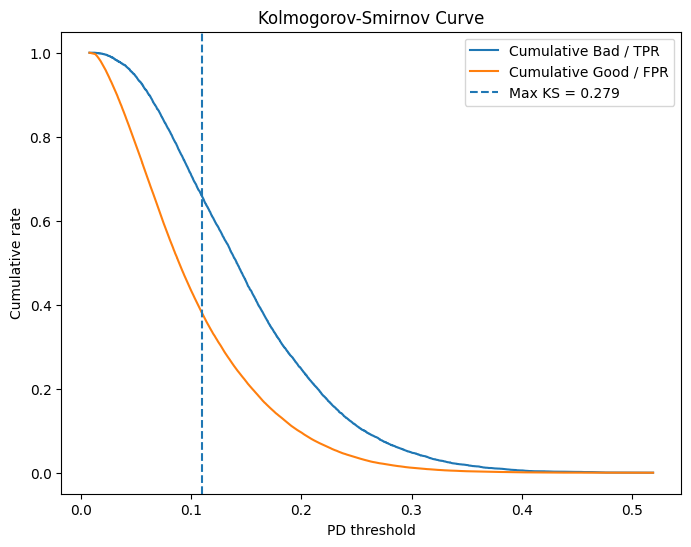

In [174]:
plot_ks_curve(ks_report)

In [175]:
#confusion matrix
'''plot_confusion_matrix(
    y_true=y_test_model,
    probabilities=test_prob,
    threshold=best_threshold,
)'''

'plot_confusion_matrix(\n    y_true=y_test_model,\n    probabilities=test_prob,\n    threshold=best_threshold,\n)'

In [176]:
#model coefficients
coefficients = pd.DataFrame({
    "feature": X_train_model.columns,
    "coefficient": pd_model.coef_[0],
})

coefficients = coefficients.sort_values(
    "coefficient",
    ascending=False,
)

display(coefficients)

,feature,coefficient
18,addr_state_woe,0.995204
25,mths_since_last_record_woe,0.891035
0,int_rate_woe,0.717359
11,tot_coll_amt_woe,0.655551
8,inq_last_6mths_woe,0.631560
15,dti_woe,0.510762
10,purpose_woe,0.510157
22,emp_length_years_woe,0.495282
7,annual_inc_woe,0.466108
14,initial_list_status_woe,0.449966


### Save the model and metadata

In [177]:
from pathlib import Path
import pickle
import pandas as pd

MODEL_DIR = PROJECT_ROOT / "models" / "pd_binning"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [178]:
#import final model and woe bins
with open(
    MODEL_DIR / "final_woe_bins.pkl",
    "rb",
) as file:
    final_bins = pickle.load(file)

In [179]:
#save metadata


coefficients.to_csv(
    MODEL_DIR / "coefficients.csv",
    index=False,
)

ks_report.to_csv(
    MODEL_DIR / "ks_report.csv",
    index=False,
)

metrics.to_csv(
    MODEL_DIR / "metrics.csv",
    index=False,
)

In [180]:
credit_risk_pipeline = {
    "lr_model": pd_model,
    "woe_bins": final_bins,
    "selected_features": list(X_train_model.columns),
    "coefficients": coefficients,
    "ks_threshold": ks_threshold,
    "ks_value": ks_value, #Kolmogorov-Smirnov statistic value
    "metrics": metrics
}

with open(
    MODEL_DIR / "credit_risk_pipeline.pkl",
    "wb",
) as file:
    pickle.dump(
        credit_risk_pipeline,
        file,
    )

print("Credit risk pipeline saved.")

Credit risk pipeline saved.


In [181]:
#verification of the saved model
with open(
    MODEL_DIR / "credit_risk_pipeline.pkl",
    "rb",
) as file:
    pipeline_check = pickle.load(file)

print(pipeline_check.keys())

print(
    "\nSelected features:",
    len(pipeline_check["selected_features"]),
)

print(
    "KS:",
    round(pipeline_check["ks_value"], 4),
)

print(
    round(pipeline_check["metrics"], 4),
)


dict_keys(['lr_model', 'woe_bins', 'selected_features', 'coefficients', 'ks_threshold', 'ks_value', 'metrics'])

Selected features: 26
KS: 0.2789
      metric   value
0   accuracy  0.6250
1  precision  0.1756
2     recall  0.6579
3   f1_score  0.2772
4    roc_auc  0.6910
5       gini  0.3820
